In [1]:
import sys
sys.path.append("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/")
import pandas as pd
import numpy as np
from SynOmics.metrics.fidelity.utils import pearson_correlation_matrix_numba, _memory_efficient_squareform
# from scipy.cluster.hierarchy import ward, fcluster, average 

# preprocessed_or_data = pd.read_csv("proprocessed_or_data.csv", index_col = 0).iloc[:,0:1000]
# or_data = pd.read_csv("../../Data/data_processed/Original_data/integrated_data_jobim.csv", index_col = 0)
or_data = pd.read_csv("ForSynthpop_processed_df.csv", index_col = 0)

In [2]:
with open('order_pred_mat.txt') as f:
    order = [int(line.strip()) for line in f]

In [3]:
import numpy as np

mat = np.load("predictor_matrix.npy")
features = or_data.columns.tolist()
features_indices = [features.index(feature) for feature in features]
var_index_zip = list(zip(features, features_indices))


# Create a dict: index -> variable name
index_to_var = {idx: name for name, idx in var_index_zip}

# Reorder variable names according to feature_order
ordered_var_names = [index_to_var[idx] for idx in order]

# Convert np.array to DataFrame
df = pd.DataFrame(mat, index=ordered_var_names, columns=ordered_var_names)

In [4]:
ordered_columns = df.columns.tolist()

ordered_or_data = or_data[ordered_columns]
ordered_or_data.head(3)

,MSKCC,Sarc,Rhab,PFS_CNSR,Age,ENSG00000233750.3,ENSG00000268903.1,ENSG00000241860.7,ENSG00000230092.7,ENSG00000228794.10,...,ENSG00000210077.1,ENSG00000209082.1,ENSG00000210107.1,ENSG00000210112.1,ENSG00000210127.1,ENSG00000210135.1,ENSG00000210144.1,ENSG00000210151.2,ENSG00000210176.1,ENSG00000210194.1
Patient_ID,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0,0,0,1,0.015438,0.261868,-0.785287,-0.312175,-1.204019,-0.990172,...,0.014622,0.014539,0.014544,0.015556,0.015565,0.015581,0.019798,0.019812,0.016714,0.014564
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,0,0,0,1,0.497567,-1.566995,1.020177,-0.312175,1.094884,0.479134,...,0.014622,0.014539,0.014544,0.015556,0.015565,0.015581,0.019798,0.019812,0.016714,0.014564
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,2,0,0,0,0.015438,0.195865,1.227886,-0.312175,0.669252,1.820245,...,0.014622,0.014539,0.014544,0.015556,0.015565,0.015581,0.019798,0.019812,0.016714,0.014564


In [6]:
 ordered_or_data.columns.get_loc("ENSG00000233967.7")

33342

In [8]:
ordered_or_data.shape

(310, 40956)

In [7]:
 ordered_or_data.columns.get_loc("ENSG00000217334.1")

33354

In [25]:
 ordered_or_data.columns.get_loc("ENSG00000214457.3")

33362

In [5]:
ordered_or_data.columns.get_loc("ENSG00000252431.1")

33570

In [5]:
ordered_or_data.columns.get_loc("ENSG00000211715.1")

34112

In [28]:
counts = []
for i in range(df.shape[0]):
    counts.append(np.sum(df.iloc[i,:]))

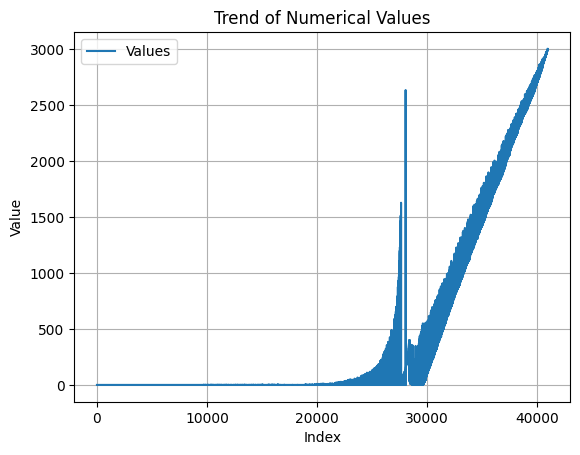

In [33]:
import matplotlib.pyplot as plt


# Line plot
plt.plot(counts, linestyle='-', label='Values')

# Add labels
plt.title("Trend of Numerical Values")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()


In [5]:
from SynOmics.metrics.fidelity.utils import extract_metadata
metadata_path = "../../Data/data_processed/Original_data/feature_metadata.json"
ordered_metadata = extract_metadata(ordered_or_data, metadata_path)
categorical_features = ordered_metadata.get("ordinal_categorical") + ordered_metadata.get("dummy_categorical") + ordered_metadata.get("missing_categorical")
numerical_features = ordered_metadata.get("numerical")

In [ ]:
from Synthpop import SynthpopSynthesizer
import time
start_time = time.time()
metadata_path = "../../Data/data_processed/Original_data/feature_metadata.json"
output_path = "test_predictor_mat"
synthpop_synth = SynthpopSynthesizer(output_path = output_path)

synthetic_pre_mat = synthpop_synth.generate_synthetic_data(
    data = ordered_or_data,
    metadata_path = metadata_path,
    R_terminal = "R441",
    data_ids = or_data.index.tolist(),
    discrete_columns = categorical_features,
    numerical_columns = numerical_features,
    seed =  42,
    enforce_rounding = False,
    enforce_min_max = False,
    method = 'cart',
    minimumlevels = 3,
    proper = False,
    n_datasets  = 1, 
    n_samples = 'auto',
    verbose = True,
    predictor_matrix = df
)
end_time = time.time()
print(end_time - start_time)

R callback write-console: 
Attaching package: ‘dplyr’

  
R callback write-console: The following objects are masked from ‘package:stats’:

    filter, lag

  
R callback write-console: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

  
R callback write-console: New version of synthpop (1.9-0) with disclosure functions
see disclosure.pdf for details and NEWS file for other changes

Find out more at https://www.synthpop.org.uk/
  


CAUTION: Your data set has fewer observations (310) than we advise.
We suggest that there should be at least 409660 observations
(100 + 10 * no. of variables used in modelling the data).
Please check your synthetic data carefully with functions
compare(), utility.tab(), and utility.gen().

